### 🤖 Corrective RAG
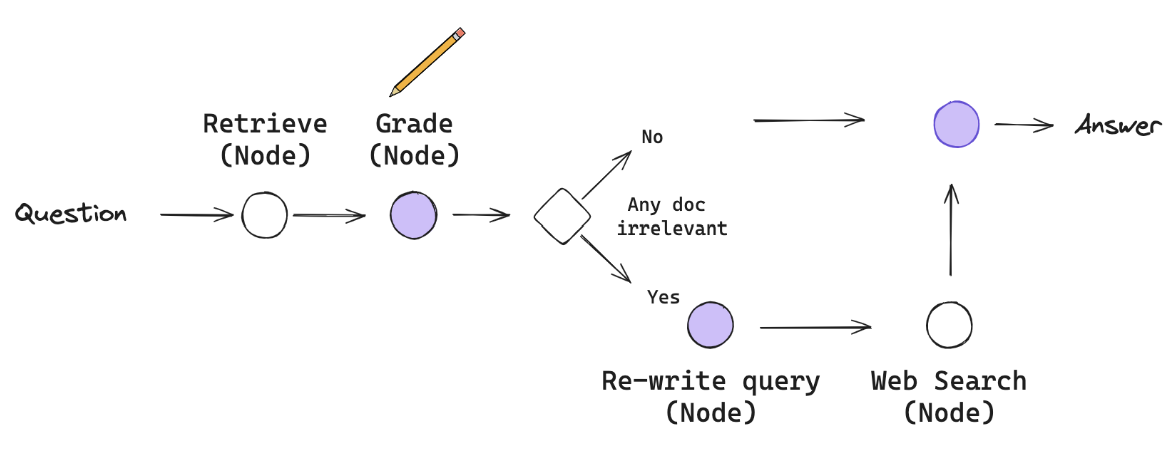

In [22]:
import os
from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langgraph.graph import StateGraph, END
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict, List
from langchain_tavily import TavilySearch
from langchain_core.documents import Document

In [3]:
load_dotenv()

True

In [4]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [11]:
llm = init_chat_model("openai:gpt-4o")

In [8]:
# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

loader = WebBaseLoader(web_paths=urls)
docs = list(loader.lazy_load())

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)

retriever=vectorstore.as_retriever()

In [12]:
### Retrieval Grader

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [18]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [33]:
# Nodes
def retrieve(state: GraphState) -> dict:
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def generate(state: GraphState) -> dict:
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "human", 
                """
                You are an assistant for question-answering tasks. 
                Use the following pieces of retrieved context to answer the question. 
                If you don't know the answer, just say that you don't know. 
                Use three sentences maximum and keep the answer concise.

                Question: {question} 

                Context: {context} 

                Answer:
                """
            )
        ]
    )

    rag_chain = prompt|llm|StrOutputParser()
    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state: GraphState) -> dict:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    prompt = PromptTemplate(
        template = """
        You are a grader assessing relevance of a retrieved document to a user question.
        If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.

        User Question:
        {question}

        Retrieved Document:
        {context}
        """,
        input_variables=['question','context']
    )

    retrieval_grader = prompt | structured_llm_grader

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "context": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state: GraphState) -> dict:
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Prompt
    system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
            ),
        ]
    )

    question_rewriter = re_write_prompt | llm | StrOutputParser()

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    web_search_tool = TavilySearch(max_results=5)
    # Web search
    docs = web_search_tool.invoke({"query": question})
    # Join all result contents into a single string
    web_results = "\n\n".join(
        d["content"] for d in docs if "content" in d
    )

    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}


In [34]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [35]:
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

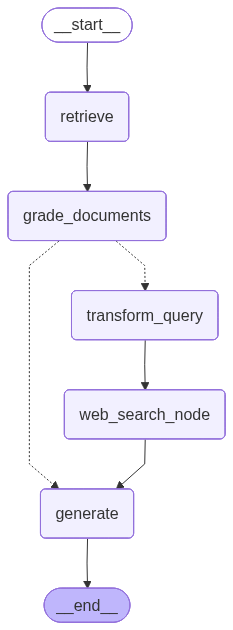

In [36]:
app

In [37]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---


c:\Users\mrinm\Downloads\MyTraining\GenerativeAI\Retrieval_Augmented_Generation\RAG_Bootcamp_Udemy\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='no'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'What are the different types of memory used in artificial intelligence agents?',
 'generation': 'Artificial intelligence agents use different types of memory: short-term memory and long-term memory. Short-term memory in AI is akin to in-context learning and is limited by context windows, while long-term memory allows for retaining and retrieving extensive information by using external vector stores and fast retrieval mechanisms. These memory types support the AI in handling complex tasks and improving over time through learning and reflection.',
 'web_search': 'Yes',
 'documents': [Document(id='b62fa006-926f-4c1a-b93b-eefc568eaf5b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The po